# Loan Approval Prediction

Predicting whether a loan application is **Approved** or **Rejected** from applicant and asset details, using Logistic Regression and Random Forest.

**Dataset:** `loan_approval_dataset.csv` (about 4,269 applications, 11 input features)

**Approach**
1. Clean the data and explore it (EDA)
2. Encode features and split into train / validation / test (70 / 15 / 15, stratified)
3. Baseline models with hyperparameter and threshold tuning
4. Feature selection by correlation
5. Manual feature engineering
6. PCA
7. Train the best model on train + validation and evaluate once on the untouched test set

**Final result:** Random Forest on the engineered features reaches **about 99.4% test accuracy** (see the last section).

**Contents**
1. Setup and Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Preprocessing and Encoding
5. Correlation Analysis
6. Train / Validation / Test Split and Scaling
7. Baseline Models
8. Feature Selection by Correlation
9. Manual Feature Engineering
10. PCA
11. Final Model
12. Summary of Results

---
## 1. Setup and Data Loading

### Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder

### Load the dataset
Check the working directory, list the datasets folder, then read the loan approval CSV.

In [2]:
os.getcwd()

'/Users/apple/Library/CloudStorage/GoogleDrive-nirbhaytinna2003@gmail.com/My Drive/Datasets'

In [3]:
os.listdir("/Users/apple/Library/CloudStorage/GoogleDrive-nirbhaytinna2003@gmail.com/My Drive/Datasets")

['ushape.csv',
 'airpassenger.csv',
 'Advertising.csv',
 'dalawampu-forecasting-electricity-by-hour-rnn-vs-l.ipynb',
 'concertriccir2.csv',
 '.DS_Store',
 'ushape.zip',
 'loan_approval_dataset.csv',
 'concertriccir2.zip',
 'loan_approval_project_presentable (1).ipynb',
 'ieee-fraud-detection',
 'archive (4).zip',
 'titanic-dataset.zip',
 'airplane.zip',
 'kaggle-cat-vs-dog-dataset.zip',
 'wine',
 'rossmann-store-sales.zip',
 'Titanic-Dataset.csv',
 'loan_approval_project_presentable.ipynb',
 'kagglecatsanddogs_3367a',
 'creditcard.csv',
 'wine.zip',
 'diabetes_prediction_dataset.csv',
 'loan_approval_project_presentable (2).ipynb',
 'rossmann-store-sales',
 'dog-vs-cat.zip',
 'ncr_ride_bookings.csv',
 'animals',
 '.ipynb_checkpoints',
 'ieee-fraud-detection.zip',
 'archive.zip',
 'archive (1).zip']

In [4]:
df = pd.read_csv("/Users/apple/Library/CloudStorage/GoogleDrive-nirbhaytinna2003@gmail.com/My Drive/Datasets/loan_approval_dataset.csv")

---
## 2. Data Cleaning

### First look at the data

In [5]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


### Missing values
No column has missing values.

In [6]:
# Check the number of missing values in each column
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

### Fix column names
The raw column names have leading spaces (e.g. `' education'`). They are stripped below.

*(The comment in the next cell says "unique values of education", but the cell prints the column names.)*

In [7]:
#checking unique values of education
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [8]:
df.columns = df.columns.str.strip() #removing leading spaces
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

### Check categorical values
The `education` values also carry a leading space, which is why the encoder categories below include it.

In [9]:
df['education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

### Drop the ID column
`loan_id` is only an identifier and carries no predictive information.

In [10]:
#removing loan id column
df.drop('loan_id', axis=1, inplace=True)

In [11]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


---
## 3. Exploratory Data Analysis (EDA)

Before encoding anything, look at the raw data: its shape, distributions, class balance and how each feature relates to the loan decision. These cells only read `df` (nothing is modified), so the rest of the notebook is unaffected.

### 3.1 Dataset overview
Shape, data types, summary statistics and duplicate check.

In [12]:
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print()
df.info()

Shape: (4269, 12)
Duplicate rows: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


### 3.2 Target balance
How many applications are approved vs rejected? An imbalanced target would affect how we read accuracy.

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

loan_status
Approved    62.22 %
Rejected    37.78 %
Name: proportion, dtype: object


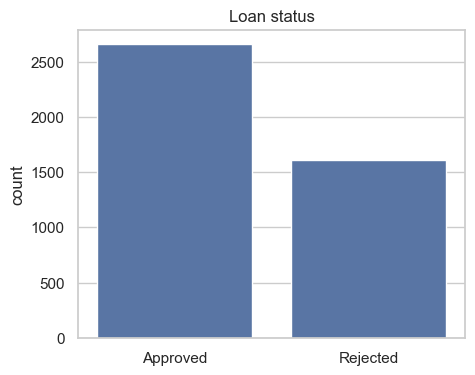

In [14]:
status = df['loan_status'].str.strip()

print(status.value_counts())
print()
print((status.value_counts(normalize=True) * 100).round(2).astype(str) + ' %')

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=status, ax=ax)
ax.set_title('Loan status')
ax.set_xlabel('')
plt.show()

### 3.3 Distributions of numeric features

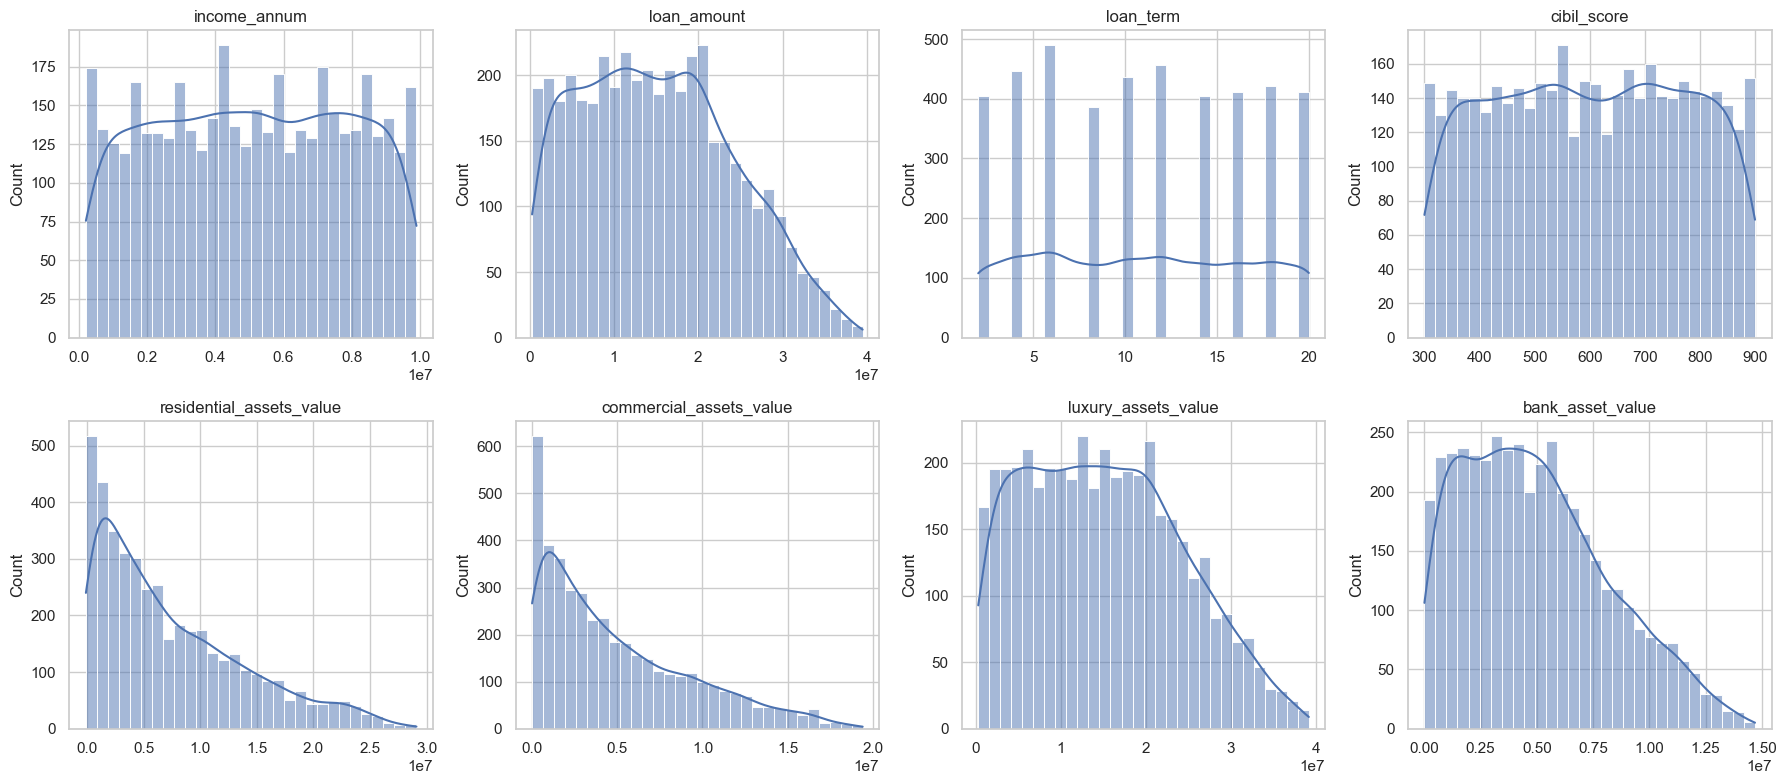

In [15]:
numeric_cols = [
    'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
    'residential_assets_value', 'commercial_assets_value',
    'luxury_assets_value', 'bank_asset_value'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

### 3.4 Categorical features vs loan status
Approval counts by education, employment type and number of dependents.

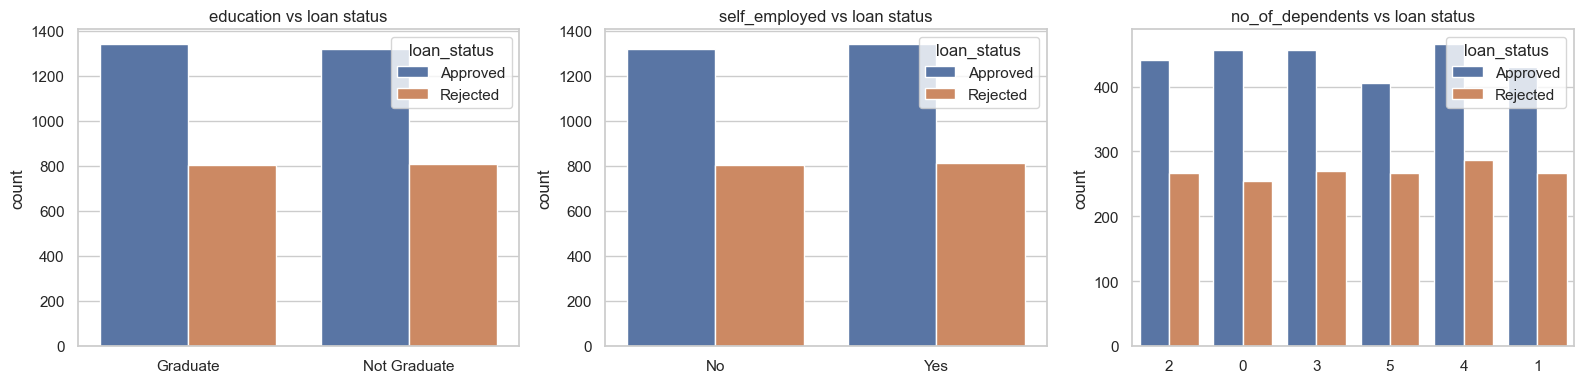

Approval rate (%) by education:
education
Graduate        62.5
Not Graduate    62.0 

Approval rate (%) by self_employed:
self_employed
No     62.2
Yes    62.2 

Approval rate (%) by no_of_dependents:
no_of_dependents
0    64.2
1    61.7
2    62.3
3    62.9
4    61.8
5    60.3 



In [16]:
cat_cols = ['education', 'self_employed', 'no_of_dependents']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=df[col].astype(str).str.strip(), hue=status, ax=ax)
    ax.set_title(f'{col} vs loan status')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

# Approval rate per category
for col in cat_cols:
    rate = (status.eq('Approved')
            .groupby(df[col].astype(str).str.strip())
            .mean().mul(100).round(1))
    print(f'Approval rate (%) by {col}:')
    print(rate.to_string(), '\n')

### 3.5 Numeric features vs loan status
Box plots split by decision. A feature whose boxes barely differ carries little signal on its own.

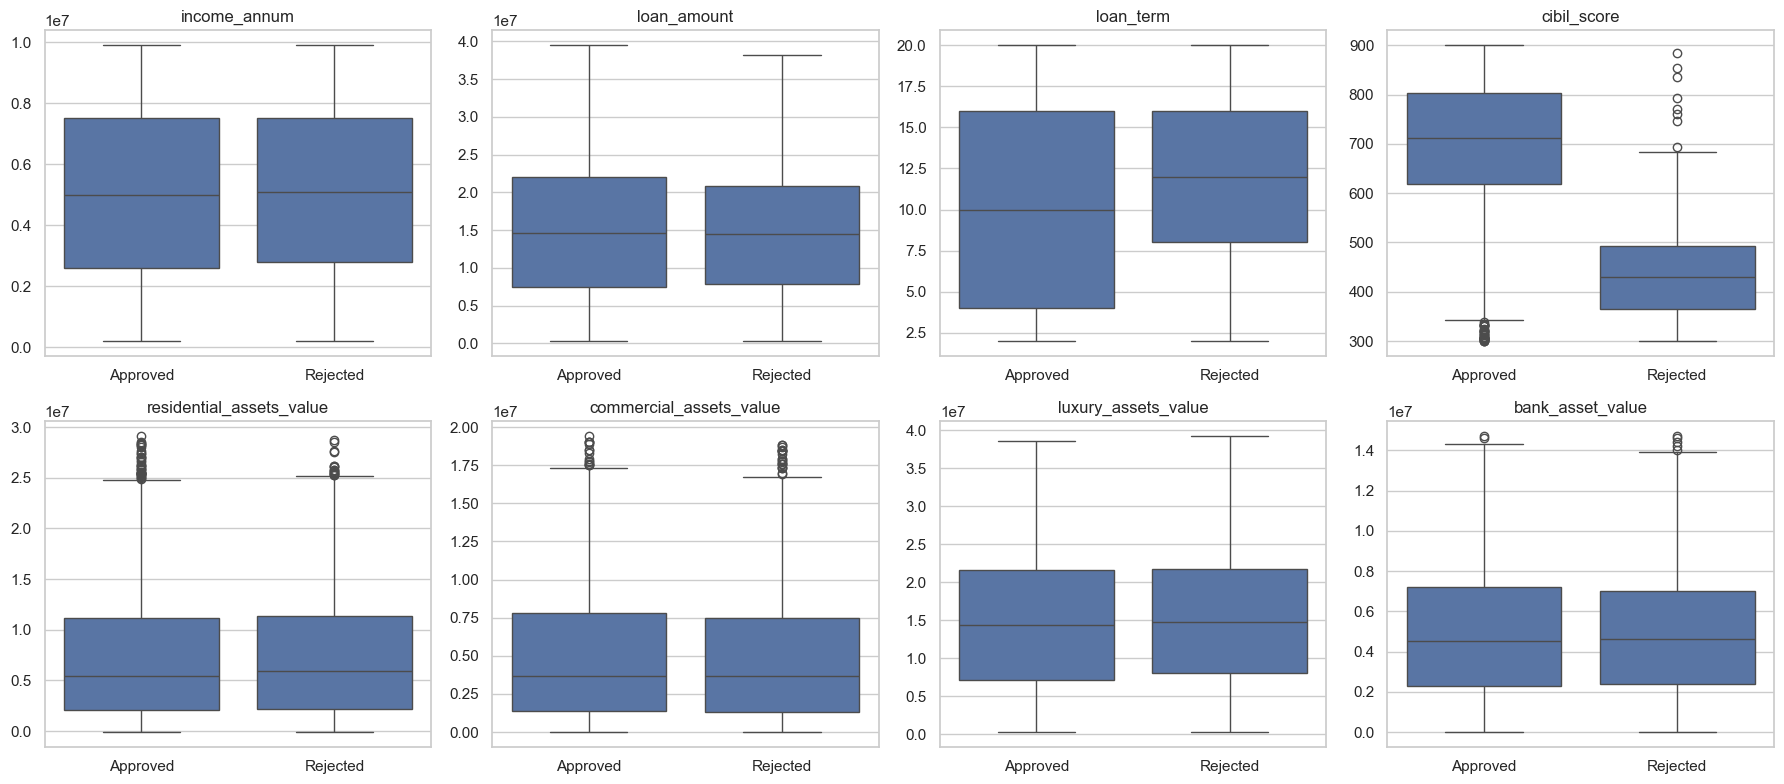

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(x=status, y=df[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 3.6 CIBIL score in detail
`cibil_score` is the strongest predictor in the correlation analysis, so look at its distribution for each outcome.

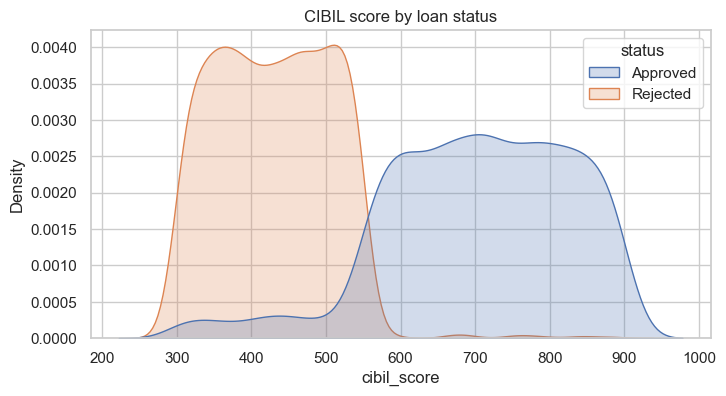

              count   mean    std    min    25%    50%    75%    max
loan_status                                                         
Approved     2656.0  703.5  125.2  300.0  618.0  711.0  803.0  900.0
Rejected     1613.0  429.5   78.4  300.0  364.0  429.0  493.0  885.0


In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=df.assign(status=status), x='cibil_score',
            hue='status', fill=True, common_norm=False, ax=ax)
ax.set_title('CIBIL score by loan status')
plt.show()

print(df.groupby(status)['cibil_score'].describe().round(1))

### 3.7 Correlation heatmap
Pairwise correlations between all numeric features and the (temporarily encoded) target. Nothing here changes `df`.

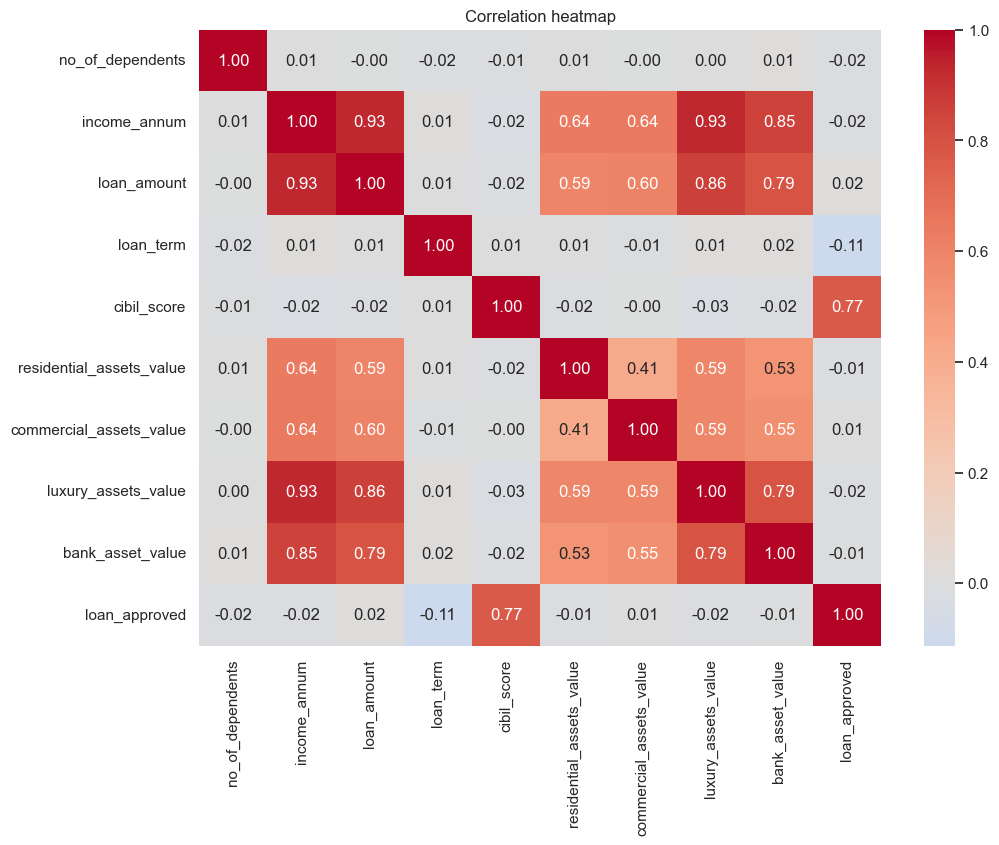

In [19]:
corr_df = df.select_dtypes(include='number').copy()
corr_df['loan_approved'] = status.eq('Approved').astype(int)

plt.figure(figsize=(11, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()

### 3.8 EDA takeaways
Run the cells above and check these against the plots:
- Class balance (3.2): whether accuracy is a fair metric or whether a majority-class baseline is high.
- `cibil_score` (3.5, 3.6): it is the strongest predictor in the correlation analysis (about 0.77 with the encoded target in Section 5), so the two classes should be clearly separated here.
- The other numeric features and the categorical ones (3.4): if their boxes and approval rates barely differ between classes, each one alone carries little signal, which is what the correlations in Section 5 also show.
- Related columns (3.7): strong correlations among income, loan amount and the asset columns motivate the combined features in Section 9 and the PCA in Section 10.

---
## 4. Preprocessing and Encoding

### Separate features and target, then encode
- Target `loan_status` is label-encoded (**Approved = 0, Rejected = 1**)
- `education` is ordinal-encoded (Not Graduate = 0, Graduate = 1)
- `self_employed` is one-hot encoded with the first level dropped
- Remaining numeric columns pass through unchanged

In [20]:


# Separate features and target
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Encode target using LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        # Education: Ordinal Encoding
        ('education', 
         OrdinalEncoder(categories=[[' Not Graduate', ' Graduate']]), 
         ['education']),
        # Self employed: One-Hot Encoding
        ('self_employed', 
         OneHotEncoder(drop='first', sparse_output=False), 
         ['self_employed'])


    ],
    remainder='passthrough'
)

# Fit and transform X
X_transformed = preprocessor.fit_transform(X)
X_transformed2 = X_transformed

### Rebuild a readable DataFrame
The `ColumnTransformer` output is a NumPy array, so column names are restored here. Two encoded columns come first, then the `no_of_dependent` column.

In [21]:
columns = []
for items in X.columns[1:]:
    columns.append(items)
columns.insert(2,'no_of_dependent')
data = pd.DataFrame(X_transformed,columns=columns)

In [22]:
data.head()

,education,self_employed,no_of_dependent,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1.0,0.0,2.0,9600000.0,29900000.0,12.0,778.0,2400000.0,17600000.0,22700000.0,8000000.0
1,0.0,1.0,0.0,4100000.0,12200000.0,8.0,417.0,2700000.0,2200000.0,8800000.0,3300000.0
2,1.0,0.0,3.0,9100000.0,29700000.0,20.0,506.0,7100000.0,4500000.0,33300000.0,12800000.0
3,1.0,0.0,3.0,8200000.0,30700000.0,8.0,467.0,18200000.0,3300000.0,23300000.0,7900000.0
4,0.0,1.0,5.0,9800000.0,24200000.0,20.0,382.0,12400000.0,8200000.0,29400000.0,5000000.0


### Attach the target for correlation analysis

In [23]:
data['loan_approval'] = y

In [24]:
data.head()

,education,self_employed,no_of_dependent,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_approval
0,1.0,0.0,2.0,9600000.0,29900000.0,12.0,778.0,2400000.0,17600000.0,22700000.0,8000000.0,0
1,0.0,1.0,0.0,4100000.0,12200000.0,8.0,417.0,2700000.0,2200000.0,8800000.0,3300000.0,1
2,1.0,0.0,3.0,9100000.0,29700000.0,20.0,506.0,7100000.0,4500000.0,33300000.0,12800000.0,1
3,1.0,0.0,3.0,8200000.0,30700000.0,8.0,467.0,18200000.0,3300000.0,23300000.0,7900000.0,1
4,0.0,1.0,5.0,9800000.0,24200000.0,20.0,382.0,12400000.0,8200000.0,29400000.0,5000000.0,1


---
## 5. Correlation Analysis

Correlation of each feature with `loan_approval`. `cibil_score` is by far the strongest signal (0.77 with the encoded target); `loan_term` is a distant second.

In [25]:

# Correlation of loan_status with all input columns
#data['loan_approval'] = (data['loan_approval']+1)%2
correlation = data.corr(numeric_only=True)['loan_approval'].sort_values(ascending=False)

correlation

loan_approval               1.000000
loan_term                   0.113036
no_of_dependent             0.018114
luxury_assets_value         0.015465
income_annum                0.015189
residential_assets_value    0.014367
bank_asset_value            0.006778
self_employed              -0.000345
education                  -0.004918
commercial_assets_value    -0.008246
loan_amount                -0.016150
cibil_score                -0.770518
Name: loan_approval, dtype: float64

---
## 6. Train / Validation / Test Split and Scaling

### Stratified split
70% train, 15% validation, 15% test. Stratification keeps the approved/rejected ratio the same in each part.

In [26]:
from sklearn.model_selection import train_test_split

# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X_transformed,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: divide the 30% equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [27]:
X_train = pd.DataFrame(X_train,columns=columns)
X_test = pd.DataFrame(X_test,columns=columns)
X_val = pd.DataFrame(X_val,columns=columns)


### Standardise numeric features
The scaler is **fit on the training set only** and applied to validation and test, which avoids data leakage.

In [28]:
from sklearn.preprocessing import StandardScaler

columns_to_scale = [
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

scaler = StandardScaler()

# Fit on training data and transform training data
X_train[columns_to_scale] = scaler.fit_transform(
    X_train[columns_to_scale]
)

# Transform validation and test using the same scaler
X_val[columns_to_scale] = scaler.transform(
    X_val[columns_to_scale]
)

X_test[columns_to_scale] = scaler.transform(
    X_test[columns_to_scale]
)

In [29]:
X_train = pd.DataFrame(X_train,columns=columns)
X_test = pd.DataFrame(X_test,columns=columns)
X_val = pd.DataFrame(X_val,columns=columns)

---
## 7. Baseline Models

### 7.1 Logistic Regression with threshold tuning
Probability thresholds from 0.1 to 0.9 are compared on the validation set.

In [30]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train, y_train)

# Probability of class 1
y_val_prob = log_reg.predict_proba(X_val)[:, 1]

# Test different probability thresholds
results = []

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    
    y_val_pred = (y_val_prob >= threshold).astype(int)
    
    accuracy = accuracy_score(y_val, y_val_pred)
    
    results.append({
        'threshold': threshold,
        'validation_accuracy': accuracy
    })

results_df = pd.DataFrame(results)

results_df

,threshold,validation_accuracy
0,0.1,0.871875
1,0.2,0.917188
2,0.3,0.932813
3,0.4,0.937500
4,0.5,0.937500
5,0.6,0.917188
6,0.7,0.900000
7,0.8,0.875000
8,0.9,0.815625


Best threshold for Logistic Regression:

In [31]:
best_lr = results_df.loc[
    results_df['validation_accuracy'].idxmax()
]
best_lr

threshold              0.4000
validation_accuracy    0.9375
Name: 3, dtype: float64

### 7.2 Random Forest hyperparameter search
Grid over `n_estimators`, `max_depth` and `min_samples_split`, scored on the validation set.

In [32]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf_results = []

for n_estimators in [100, 200, 500]:
    for max_depth in [None, 5, 10, 20]:
        for min_samples_split in [2, 5, 10]:
            
            model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=42,
                n_jobs=-1
            )
            
            model.fit(X_train, y_train)
            
            y_val_pred = model.predict(X_val)
            accuracy = accuracy_score(y_val, y_val_pred)
            
            rf_results.append({
                'n_estimators': n_estimators,
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'validation_accuracy': accuracy
            })

Results sorted by validation accuracy:

In [33]:
rf_results = pd.DataFrame(rf_results)

rf_results.sort_values(
    'validation_accuracy',
    ascending=False
)

,n_estimators,max_depth,min_samples_split,validation_accuracy
35,500,20.0,10,0.985938
14,200,NaN,10,0.985938
33,500,20.0,2,0.985938
32,500,10.0,10,0.985938
30,500,10.0,2,0.985938
26,500,NaN,10,0.985938
24,500,NaN,2,0.985938
23,200,20.0,10,0.985938
22,200,20.0,5,0.985938
13,200,NaN,5,0.985938


Best Random Forest configuration:

In [34]:

best_rf = rf_results.loc[
    rf_results['validation_accuracy'].idxmax()
]

print("\nBest Random Forest:")
print(best_rf)


Best Random Forest:
n_estimators           200.000000
max_depth                     NaN
min_samples_split        5.000000
validation_accuracy      0.985938
Name: 13, dtype: float64


---
## 8. Feature Selection by Correlation

Selecting top 3,5,7,9 features as per correlation

Rank the features by absolute correlation with the target (computed on the training set):

In [35]:


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Create DataFrame from transformed training data


X_train_df = pd.DataFrame(X_train, columns=columns)
X_val_df = pd.DataFrame(X_val, columns= columns)

# Calculate correlation with target
corr = X_train_df.corrwith(pd.Series(y_train, index=X_train_df.index))

# Rank features by absolute correlation
ranked_features = corr.abs().sort_values(ascending=False)

print(ranked_features)

cibil_score                 0.764076
loan_term                   0.107899
residential_assets_value    0.035494
no_of_dependent             0.023840
income_annum                0.023290
luxury_assets_value         0.019240
bank_asset_value            0.015804
loan_amount                 0.014901
education                   0.003146
self_employed               0.002408
commercial_assets_value     0.000681
dtype: float64


Train both models on the top 3, 5, 7 and 9 features and compare validation accuracy:

In [36]:
results = []

for n_features in [3, 5, 7, 9]:

    # Select top n features
    selected_features = ranked_features.head(n_features).index

    X_train_selected = X_train_df[selected_features]
    X_val_selected = X_val_df[selected_features]

    # -------------------------
    # Logistic Regression
    # -------------------------
    log_reg = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    log_reg.fit(X_train_selected, y_train)

    y_pred_log = log_reg.predict(X_val_selected)

    log_accuracy = accuracy_score(y_val, y_pred_log)

    results.append({
        'Model': 'Logistic Regression',
        'Features': n_features,
        'Validation Accuracy': log_accuracy
    })

    # -------------------------
    # Random Forest
    # -------------------------
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_selected, y_train)

    y_pred_rf = rf.predict(X_val_selected)

    rf_accuracy = accuracy_score(y_val, y_pred_rf)

    results.append({
        'Model': 'Random Forest',
        'Features': n_features,
        'Validation Accuracy': rf_accuracy
    })


results_df = pd.DataFrame(results)

results_df

,Model,Features,Validation Accuracy
0,Logistic Regression,3,0.934375
1,Random Forest,3,0.953125
2,Logistic Regression,5,0.935937
3,Random Forest,5,0.957812
4,Logistic Regression,7,0.935937
5,Random Forest,7,0.965625
6,Logistic Regression,9,0.937500
7,Random Forest,9,0.982812


---
## 9. Manual Feature Engineering

Creating manual features

Two combined features replace six raw columns:
- **`total_asset_value`**: sum of residential, commercial, luxury and bank assets
- **`loan_to_income`**: loan amount divided by annual income

In [37]:
X_transformed2 = pd.DataFrame(X_transformed2,columns=columns)

In [38]:
# Create total asset value
X_transformed2['total_asset_value'] = (
    X_transformed2['residential_assets_value']
    + X_transformed2['commercial_assets_value']
    + X_transformed2['luxury_assets_value']
    + X_transformed2['bank_asset_value']
)

# Create loan-to-income ratio
X_transformed2['loan_to_income'] = (
    X_transformed2['loan_amount'] / X_transformed2['income_annum']
)

# Remove individual asset columns and original loan/income columns
X_transformed2.drop(
    columns=[
        'residential_assets_value',
        'commercial_assets_value',
        'luxury_assets_value',
        'bank_asset_value',
        'loan_amount',
        'income_annum'
    ],
    inplace=True
)

### Re-split with the engineered features
Same split settings as before (70 / 15 / 15, stratified, `random_state=42`).

In [39]:
from sklearn.model_selection import train_test_split
column2= X_transformed2.columns
# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X_transformed2,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: divide the 30% equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [40]:
X_train.head()

,education,self_employed,no_of_dependent,loan_term,cibil_score,total_asset_value,loan_to_income
2173,1.0,0.0,0.0,2.0,383.0,27600000.0,3.346939
2611,0.0,1.0,3.0,12.0,369.0,20400000.0,2.958333
2771,1.0,0.0,1.0,2.0,358.0,13700000.0,2.620690
1177,1.0,0.0,4.0,20.0,809.0,25500000.0,2.542857
2370,1.0,1.0,3.0,8.0,641.0,2200000.0,3.333333


### 9.1 Logistic Regression (engineered features)

In [41]:
# Fit Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train, y_train)

# Get probability of class 1
y_val_prob = log_reg.predict_proba(X_val)[:, 1]

# Test different thresholds
logistic_results_manual = []

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:

    y_val_pred = (y_val_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_val, y_val_pred)

    logistic_results_manual.append({
        'Threshold': threshold,
        'Validation Accuracy': accuracy
    })

logistic_results_manual = pd.DataFrame(logistic_results_manual)

logistic_results_manual

,Threshold,Validation Accuracy
0,0.1,0.815625
1,0.2,0.862500
2,0.3,0.875000
3,0.4,0.876563
4,0.5,0.867188
5,0.6,0.853125
6,0.7,0.834375
7,0.8,0.798438
8,0.9,0.734375


In [42]:
log_result_best_manual = logistic_results_manual.loc[
    logistic_results_manual['Validation Accuracy'].idxmax()
]

### 9.2 Random Forest (engineered features)
A wider grid, including `min_samples_leaf`.

In [43]:
rf_results = []

for n_estimators in [50, 100, 200, 500]:
    for max_depth in [None, 5, 10, 15, 20]:
        for min_samples_split in [2, 5, 10]:
            for min_samples_leaf in [1, 2, 4]:

                rf = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    random_state=42,
                    n_jobs=-1
                )

                rf.fit(X_train, y_train)

                y_val_pred = rf.predict(X_val)

                accuracy = accuracy_score(y_val, y_val_pred)

                rf_results.append({
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split,
                    'min_samples_leaf': min_samples_leaf,
                    'validation_accuracy': accuracy
                })

rf_results = pd.DataFrame(rf_results)

Top 10 configurations. Several tie at about 99.8% validation accuracy, and the simplest one (`n_estimators=50`, no depth limit) is used for the final model.

In [44]:
rf_results.sort_values(
    'validation_accuracy',
    ascending=False
).head(10)

,n_estimators,max_depth,min_samples_split,min_samples_leaf,validation_accuracy
0,50,NaN,2,1,0.998437
113,200,10.0,5,4,0.998437
115,200,10.0,10,2,0.998437
116,200,10.0,10,4,0.998437
117,200,15.0,2,1,0.998437
118,200,15.0,2,2,0.998437
119,200,15.0,2,4,0.998437
120,200,15.0,5,1,0.998437
121,200,15.0,5,2,0.998437
122,200,15.0,5,4,0.998437


---
## 10. PCA

Dimensionality reduction to 3, 5 and 7 components, tested with both models.

In [45]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

In [46]:
X_train_pca, X_temp_pca, y_train_pca, y_temp_pca = train_test_split(
    X_transformed,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_pca, X_test_pca, y_val_pca, y_test_pca = train_test_split(
    X_temp_pca,
    y_temp_pca,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_pca
)

### Search over components and hyperparameters

In [47]:
pca_results = []

for n_components in [3, 5, 7]:

    # -------------------------
    # PCA
    # -------------------------
    pca = PCA(
        n_components=n_components,
        random_state=42
    )

    X_train_pca_transformed = pca.fit_transform(X_train_pca)
    X_val_pca_transformed = pca.transform(X_val_pca)

    # -------------------------
    # Logistic Regression
    # -------------------------
    log_reg = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    log_reg.fit(
        X_train_pca_transformed,
        y_train_pca
    )

    y_val_prob = log_reg.predict_proba(
        X_val_pca_transformed
    )[:, 1]

    # Multiple thresholds
    for threshold in [
        0.1, 0.2, 0.3, 0.4, 0.5,
        0.6, 0.7, 0.8, 0.9
    ]:

        y_pred = (
            y_val_prob >= threshold
        ).astype(int)

        accuracy = accuracy_score(
            y_val_pca,
            y_pred
        )

        pca_results.append({
            'Model': 'Logistic Regression',
            'Components': n_components,
            'Threshold': threshold,
            'n_estimators': None,
            'max_depth': None,
            'min_samples_split': None,
            'min_samples_leaf': None,
            'Validation Accuracy': accuracy
        })

    # -------------------------
    # Random Forest
    # -------------------------
    for n_estimators in [50, 100, 200]:
        for max_depth in [None, 5, 10, 20]:
            for min_samples_split in [2, 5, 10]:
                for min_samples_leaf in [1, 2, 4]:

                    rf = RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        min_samples_leaf=min_samples_leaf,
                        random_state=42,
                        n_jobs=-1
                    )

                    rf.fit(
                        X_train_pca_transformed,
                        y_train_pca
                    )

                    y_val_pred_rf = rf.predict(
                        X_val_pca_transformed
                    )

                    rf_accuracy = accuracy_score(
                        y_val_pca,
                        y_val_pred_rf
                    )

                    pca_results.append({
                        'Model': 'Random Forest',
                        'Components': n_components,
                        'Threshold': 0.5,
                        'n_estimators': n_estimators,
                        'max_depth': max_depth,
                        'min_samples_split': min_samples_split,
                        'min_samples_leaf': min_samples_leaf,
                        'Validation Accuracy': rf_accuracy
                    })

In [48]:
pca_results = pd.DataFrame(pca_results)

### PCA results: Logistic Regression (top 10)

In [49]:
pca_results[
    pca_results['Model'] == 'Logistic Regression'
].sort_values(
    'Validation Accuracy',
    ascending=False
).head(10)

,Model,Components,Threshold,n_estimators,max_depth,min_samples_split,min_samples_leaf,Validation Accuracy
240,Logistic Regression,7,0.7,NaN,NaN,NaN,NaN,0.945312
239,Logistic Regression,7,0.6,NaN,NaN,NaN,NaN,0.932813
241,Logistic Regression,7,0.8,NaN,NaN,NaN,NaN,0.914062
238,Logistic Regression,7,0.5,NaN,NaN,NaN,NaN,0.912500
237,Logistic Regression,7,0.4,NaN,NaN,NaN,NaN,0.868750
242,Logistic Regression,7,0.9,NaN,NaN,NaN,NaN,0.839063
236,Logistic Regression,7,0.3,NaN,NaN,NaN,NaN,0.815625
235,Logistic Regression,7,0.2,NaN,NaN,NaN,NaN,0.756250
234,Logistic Regression,7,0.1,NaN,NaN,NaN,NaN,0.664062
6,Logistic Regression,3,0.7,NaN,NaN,NaN,NaN,0.621875


### PCA results: Random Forest (top 10)

In [50]:
pca_results[
    pca_results['Model'] == 'Random Forest'
].sort_values(
    'Validation Accuracy',
    ascending=False
).head(10)

,Model,Components,Threshold,n_estimators,max_depth,min_samples_split,min_samples_leaf,Validation Accuracy
304,Random Forest,7,0.5,100.0,10.0,10.0,2.0,0.957812
281,Random Forest,7,0.5,100.0,NaN,2.0,4.0,0.957812
322,Random Forest,7,0.5,200.0,NaN,10.0,2.0,0.957812
320,Random Forest,7,0.5,200.0,NaN,5.0,4.0,0.957812
335,Random Forest,7,0.5,200.0,10.0,2.0,4.0,0.957812
317,Random Forest,7,0.5,200.0,NaN,2.0,4.0,0.957812
314,Random Forest,7,0.5,100.0,20.0,10.0,4.0,0.957812
313,Random Forest,7,0.5,100.0,20.0,10.0,2.0,0.957812
338,Random Forest,7,0.5,200.0,10.0,5.0,4.0,0.957812
340,Random Forest,7,0.5,200.0,10.0,10.0,2.0,0.957812


### Best PCA configuration overall
PCA does not beat the engineered-feature Random Forest.

In [51]:
pca_results.loc[
    pca_results['Validation Accuracy'].idxmax()
]

Model                  Random Forest
Components                         7
Threshold                        0.5
n_estimators                    50.0
max_depth                        NaN
min_samples_split                2.0
min_samples_leaf                 4.0
Validation Accuracy         0.957812
Name: 245, dtype: object

---
## 11. Final Model

The best configuration, a **Random Forest on the engineered features** (`n_estimators=50`, `max_depth=None`, `min_samples_split=2`, `min_samples_leaf=1`), is trained on **training + validation** data and evaluated once on the untouched **test set**.

**Test accuracy: 0.9938 (about 99.4%)**

In [52]:
#fitting best model on both training and val and checking on testing


In [53]:
X_train = pd.DataFrame(X_train,columns=column2)
X_test = pd.DataFrame(X_test,columns=column2)
X_val = pd.DataFrame(X_val,columns=column2)
y_train = pd.DataFrame(y_train)
y_val = pd.DataFrame(y_val)
#fitting best model (Note: I am writing this at the end, correct it accordinly)
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Combine training and validation data
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

# Best Random Forest model
best_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train on both training + validation data
best_rf.fit(X_train_final, y_train_final)

# Final evaluation on untouched test set
y_test_pred = best_rf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9937597503900156


/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


---
## 12. Summary of Results

Validation accuracy unless stated otherwise.

| Approach | Logistic Regression | Random Forest |
|---|---|---|
| Baseline (all features, scaled) | 0.9375 (threshold 0.4 or 0.5) | 0.9859 |
| Top 9 features by correlation | 0.9375 | 0.9828 |
| Engineered features | 0.8766 (threshold 0.4) | **0.9984** |
| PCA (7 components) | 0.9453 (threshold 0.7) | 0.9578 |

**Final model:** Random Forest on engineered features, trained on train + validation, **test accuracy about 99.4%**.

**Takeaways**
- `cibil_score` dominates the prediction.
- Random Forest clearly outperforms Logistic Regression on this data.
- Combining the asset columns and computing loan-to-income helped the tree model but hurt the linear one.
- PCA lost information and did not help.